# **Загрузка данных и первичный осмотр**

## **Импорт необходимых библиотек**

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

## **Загрузка учебного датасета**

In [2]:
dataset = pd.read_csv("S02-hw-dataset.csv")

## **Вывод**

#### **Первые строки датасета**

In [3]:
dataset.head(10)

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296
5,6,120.0,FR,-1,785
6,7,46.0,RU,0,0
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511


#### **Информация о столбцах и типах**

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


#### **Базовые описательные статистики**

In [5]:
dataset.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


In [6]:
dataset.columns

Index(['user_id', 'age', 'country', 'purchases', 'revenue'], dtype='object')

# **Пропуски, дубликаты и базовый контроль качества**

## **Доля пропусков в каждом столбце**

In [7]:
dataset.isna().mean()

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

Во всех столбцах, кроме столбца age, доля пропусков равна 0. Следовательно пропуски есть только в толбце age.

## **Наличие полностью дублирующих строк**

In [8]:
duplicates = dataset[dataset.duplicated(keep=False)]
print("Количество полностью дублирующих строк:", dataset.duplicated().sum())
print(duplicates)

Количество полностью дублирующих строк: 1
    user_id   age country  purchases  revenue
9        10  24.0      RU          7      511
40       10  24.0      RU          7      511


## **«Подозрительные» случаи**

#### **Отрицательные значения в полях, где их не должно быть**

In [9]:
dataset['purchases'].describe()

count    41.000000
mean      4.829268
std       2.710189
min      -1.000000
25%       3.000000
50%       5.000000
75%       7.000000
max      11.000000
Name: purchases, dtype: float64

Отрицательная покупка выглядит подозрительно. Посмотрим детали.

In [10]:
purchase = dataset[(dataset['purchases'] == -1)]
print(purchase)

   user_id    age country  purchases  revenue
5        6  120.0      FR         -1      785


Была совершена отрицательная покупка, с которой получили доход суммой 785. Это странно.

#### **Нереалистичные значения**

In [11]:
dataset['age'].describe()

count     39.000000
mean      36.512821
std       18.304259
min        5.000000
25%       24.000000
50%       33.000000
75%       45.500000
max      120.000000
Name: age, dtype: float64

Минимальный возраст покупателей 5 и максимальный 120 кажутся странными. Посмотрим на эти данные подробнее.

In [12]:
age = dataset[(dataset['age'] == 5) | (dataset['age'] == 120)]
print(age)

    user_id    age country  purchases  revenue
5         6  120.0      FR         -1      785
20       21    5.0      RU          8     1488


Итак, 120-летний покупатель - тот самый покупатель с отрицательной покупкой. Пятилетний ребёнок, сделавший восемь покупок суммой на 1488 рублей выглядит сомнительно.

#### **Другие противоречия**

In [13]:
dataset['revenue'].describe()

count      41.000000
mean      820.048780
std       613.127269
min         0.000000
25%       432.000000
50%       693.000000
75%      1115.000000
max      2475.000000
Name: revenue, dtype: float64

Минимальная доходность равна нулю. Это возможно, но стоит проверить.

In [14]:
revenue = dataset[(dataset['revenue'] == 0)]
print(revenue)

    user_id   age country  purchases  revenue
6         7  46.0      RU          0        0
10       11  24.0      US          4        0
17       18  24.0      RU          0        0
33       34  28.0      FR          0        0


Доходность равная нулю при нулевых покупках - это номально. Но когда было совершено 4 покупки (10 строка), а доходность стоставляет 0, это уже странно.

In [15]:
null_age = dataset[dataset['age'].isna()]
print(null_age)

    user_id  age country  purchases  revenue
4         5  NaN      DE          6     1296
12       13  NaN      US          9      630


Нет данных о возрасте.

## **Какие проблемы качества данных были обнаружены?**

В результате проверки данных, было обнаружено несколько подозрительных строк:
- Строка 5 с отрицательной покупкой, при которой был получен доход, а также очень большой возраст покупателя (120);
- Строка 20 с пятилетним ребёнком, совершившим 8 покупок на сумму 1488 рублей;
- Строка 10 в которой было совершено 4 покупки, и при этом не получено никакого дохода;
- Строка 40 полностью дублирует строку 9;
- Строка 4 не содержит данные о возрасте;
- Строка 12 не содержит данные о возрасте.

В итоге всего было обнаружено 6 строк с проблемными данными.

# **Базовый EDA: группировки, агрегаты и частоты**

In [16]:
dataset1 = dataset.drop_duplicates().reset_index(drop=True) #удаляем дубликаты

## **Частоты для одной категориальной переменной**

In [17]:
country_frequency = dataset1['country'].value_counts()
print(country_frequency)

country
FR    12
RU    12
US     8
DE     6
CN     2
Name: count, dtype: int64


## **Выполнение осмысленной группировки с агрегатами через groupby**

#### **Среднее, максимум и сумма по количественным признакам в разрезе категорий**

In [18]:
group_country = dataset1.groupby('country').agg(
    users = ('user_id', 'count'),
    purchases_mean = ('purchases', 'mean'),
    purchases_max = ('purchases', 'max'),
    purchases_sum = ('purchases', 'sum'),
    revenue_mean = ('revenue', 'mean'),
    revenue_max = ('revenue', 'max'),
    revenue_sum = ('revenue', 'sum'),
).round(2)

print(group_country)

         users  purchases_mean  purchases_max  purchases_sum  revenue_mean  \
country                                                                      
CN           2            4.50              7              9       1054.00   
DE           6            6.50             11             39       1445.50   
FR          12            4.25              7             51        675.92   
RU          12            4.58              8             55        813.33   
US           8            4.62              9             37        557.38   

         revenue_max  revenue_sum  
country                            
CN              1652         2108  
DE              2475         8673  
FR              1608         8111  
RU              2086         9760  
US               980         4459  


## **Основные наблюдения**

Больше всего покупателей принадлежит к России и Франции (12). Меньше всего - к Китаю (2) и Германии (6).

В сумме больше всего покупок было совершено россиянами (55), меньше всего - китайцами (9), но их в шесть раз меньше, так что это не удивительно. 

В среднем немцы совершают больше покупок чем все остальные национальности (6.5). 

Максимальное число покупок, совершенное одним покупателем, тоже относится к немцу (11). 

В сумме больше всего дохода приносят русские (9760), меньше всего китайцы (2108). 

В среднем немцы принесли больше дохода чем все остальные (1445.5). 

Самая дорогая покупка была совершена немцем (2475).

Интересно то, что Германия при довольно малом количестве покупателей (6) показывают самые высокие средние и максимальные показатели выручки, в то время как США, имея 8 пользователей, показывают наименьшие среднюю (557.38) и максимальную (980) выручку.

# **Визуализация данных в Matplotlib**

In [19]:
dataset2 = dataset1[(dataset1['age'].between(18, 100)) & (dataset1['purchases'] >= 0)].drop(index=10).copy() # создаём датасет без подозрительных данных

## **Гистограмма**

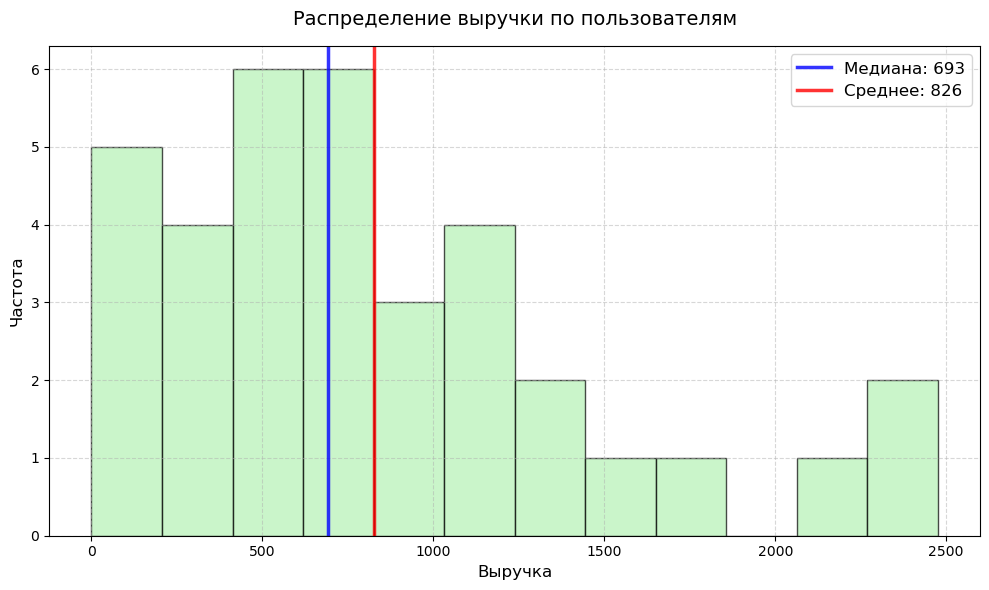

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(dataset2['revenue'], bins=12, color='#B4F2B4', edgecolor='black', alpha=0.7)
plt.title('Распределение выручки по пользователям', fontsize=14, pad=15)
plt.xlabel('Выручка', fontsize=12)
plt.ylabel('Частота', fontsize=12)

revenue_median = dataset2['revenue'].median()
revenue_mean = dataset2['revenue'].mean()

plt.axvline(revenue_median, color='blue', linewidth=2.5, alpha=0.8, label=f'Медиана: {round(revenue_median)}')
plt.axvline(revenue_mean, color='red', linewidth=2.5, alpha=0.8, label=f'Среднее: {round(revenue_mean)}')

plt.grid(linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Медиана ниже среднего - значит, у большинства клиентов выручка небольшая, а среднее завышают несколько пользователей, делающих крупные покупки.

## **Боксплот (boxplot)**

<Figure size 1000x600 with 0 Axes>

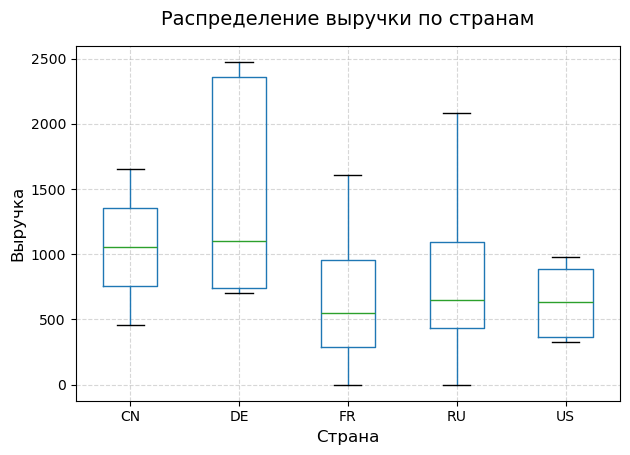

In [21]:
plt.figure(figsize=(10, 6))
dataset2.boxplot(column='revenue', by='country', grid=True)
plt.title('Распределение выручки по странам', fontsize=14, pad=15)
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.suptitle('')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Германия приносит больше всех выручки, в то время как США демонстрирует самые низкие показатели.

## **Scatter plot (диаграмма рассеяния)**

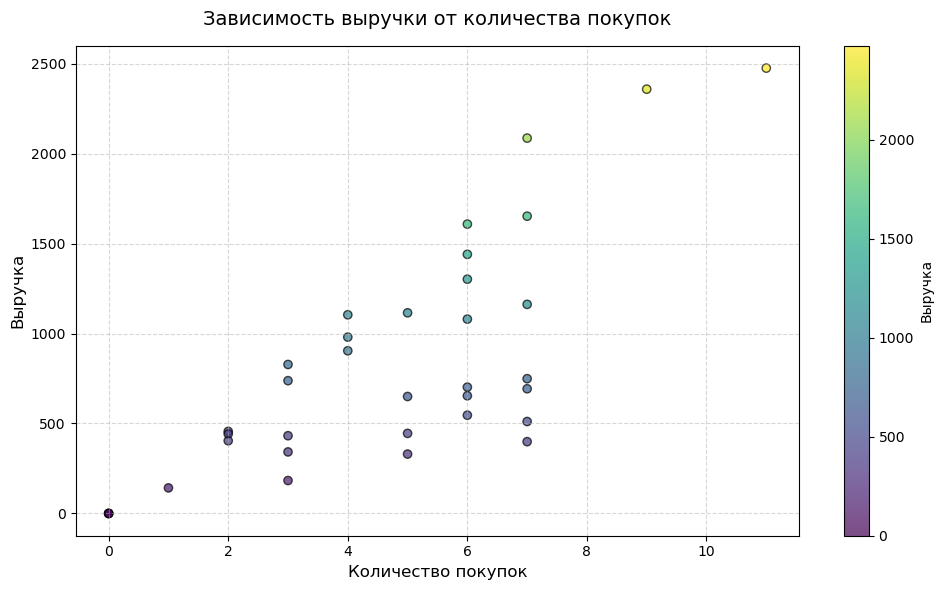

In [22]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(dataset2['purchases'], dataset2['revenue'], 
                      c=dataset2['revenue'], cmap='viridis', alpha=0.7, edgecolors='black')
plt.title('Зависимость выручки от количества покупок', fontsize=14, pad=15)
plt.xlabel('Количество покупок', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.colorbar(scatter, label='Выручка')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figures/scatter.png")
plt.show()

Выручка растёт с увеличением количества покупок.